In [23]:
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
import matplotlib
from PIL import Image

import matplotlib.animation as animation
from IPython.display import HTML

In [14]:
def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())

class SuperQuadric:
    def __init__(self, a1=1.0, a2=1.0, a3=1.0, e1=1.0, e2=1.0):
        """
        Initialize a superquadric surface.

        Parameters:
        - a1, a2, a3: scale along x, y, z
        - e1: exponent in elevation (phi)
        - e2: exponent in azimuth (theta)
        """
        self.a1 = a1
        self.a2 = a2
        self.a3 = a3
        self.e1 = e1
        self.e2 = e2
        self.eps = 1e-8  # Stability epsilon

    def signed_power(self, x, e):
        """Stable version of sign(x) * |x|^e"""
        return np.sign(x) * (np.maximum(np.abs(x), self.eps) ** e)

    def inverse_signed_power(self, y, e):
        return np.sign(y) * (np.abs(y) + 1e-12) ** (1.0 / e)

    def r(self, theta, phi):
        """
        Map (theta, phi) to a point on the superquadric surface.

        Parameters:
        - theta: azimuth [-π, π]
        - phi: elevation [-π/2, π/2]

        Returns:
        - np.array([x, y, z])
        """
        ct = self.signed_power(np.cos(theta), self.e2)
        st = self.signed_power(np.sin(theta), self.e2)
        cp = self.signed_power(np.cos(phi), self.e1)
        sp = self.signed_power(np.sin(phi), self.e1)

        x = self.a1 * cp * ct
        y = self.a2 * cp * st
        z = self.a3 * sp
        return np.array([x, y, z])

    def theta_phi(self, point):
        """
        Invert r(theta, phi): Recover (theta, phi) from surface point (x, y, z)
        Assumes point lies on the surface.
        """
        x, y, z = point
        a1, a2, a3 = self.a1, self.a2, self.a3
        e1, e2 = self.e1, self.e2

        # --- Invert phi from z ---
        sin_phi = np.sign(z) * (np.abs(z / a3) ** (1 / e1))
        sin_phi = np.clip(sin_phi, -1.0, 1.0)
        phi = np.arcsin(sin_phi)

        # --- Recover cos(phi)^e1 ---
        cos_phi = np.cos(phi)
        eta = np.sign(cos_phi) * (np.abs(cos_phi) ** e1)

        # --- Compute intermediate xi and psi ---
        xi = x / (a1 * eta)
        psi = y / (a2 * eta)

        # --- Recover theta from xi, psi ---
        cos_theta = np.sign(xi) * (np.abs(xi) ** (1 / e2))
        sin_theta = np.sign(psi) * (np.abs(psi) ** (1 / e2))

        # Clip again to safe domain
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        sin_theta = np.clip(sin_theta, -1.0, 1.0)

        theta = np.arctan2(sin_theta, cos_theta)

        return theta, phi

    def surface_normal(self, theta, phi):
        """
        Compute the unit surface normal at (theta, phi) on the superquadric.
        
        This function computes the analytic partial derivatives of r(theta, phi)
        and returns the normalized cross product of (dr/dtheta) and (dr/dphi).
        
        Parameters:
        - theta: azimuth angle (in [-π, π])
        - phi:   elevation angle (in [-π/2, π/2])
        
        Returns:
        - A numpy array [nx, ny, nz] representing the unit normal vector.
        """
        eps = 1e-12  # small constant for numerical stability
        a1, a2, a3 = self.a1, self.a2, self.a3
        e1, e2 = self.e1, self.e2

        # Precompute trigonometric functions
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)
        cos_phi   = np.cos(phi)
        sin_phi   = np.sin(phi)
        
        # Compute signed powers (using your provided function)
        ct = self.signed_power(cos_theta, e2)
        st = self.signed_power(sin_theta, e2)
        cp = self.signed_power(cos_phi, e1)
        sp = self.signed_power(sin_phi, e1)
        
        # Partial derivative with respect to theta
        # d/dtheta[ signed_power(cos(theta), e2) ] = - e2 * (|cos(theta)|+eps)^(e2-1)* sin(theta)
        dct_dtheta = -e2 * (np.abs(cos_theta) + eps)**(e2 - 1) * sin_theta
        # d/dtheta[ signed_power(sin(theta), e2) ] =   e2 * (np.abs(sin_theta)+eps)^(e2-1)* cos(theta)
        dst_dtheta =  e2 * (np.abs(sin_theta) + eps)**(e2 - 1) * cos_theta

        dr_dtheta = np.array([
            a1 * cp * dct_dtheta,
            a2 * cp * dst_dtheta,
            0.0
        ])
        
        # Partial derivative with respect to phi
        # d/dphi[ signed_power(cos(phi), e1) ] = - e1 * (|cos(phi)|+eps)^(e1-1)* sin(phi)
        dcp_dphi = -e1 * (np.abs(cos_phi) + eps)**(e1 - 1) * sin_phi
        # d/dphi[ signed_power(sin(phi), e1) ] =   e1 * (np.abs(sin_phi)+eps)^(e1-1)* cos(phi)
        dsp_dphi =  e1 * (np.abs(sin_phi) + eps)**(e1 - 1) * cos_phi

        dr_dphi = np.array([
            a1 * dcp_dphi * ct,
            a2 * dcp_dphi * st,
            a3 * dsp_dphi
        ])
        
        # Compute the cross product of the tangent vectors
        N = np.cross(dr_dtheta, dr_dphi)
        norm = np.linalg.norm(N)
        if norm < eps:
            return np.array([0.0, 0.0, 1.0])
        return N / norm
    
    def generate_mesh(self, resolution=100):
        theta = np.linspace(-np.pi, np.pi, resolution)
        phi = np.linspace(-np.pi / 2, np.pi / 2, resolution)
        theta_grid, phi_grid = np.meshgrid(theta, phi)

        x = np.zeros_like(theta_grid)
        y = np.zeros_like(theta_grid)
        z = np.zeros_like(theta_grid)

        for i in range(resolution):
            for j in range(resolution):
                p = self.r(theta_grid[i, j], phi_grid[i, j])
                x[i, j], y[i, j], z[i, j] = p

        return x, y, z

    def project_to_surface(self, point):
        """Approximate projection using (theta, phi) map."""
        theta, phi = self.theta_phi(point)
        return self.r(theta, phi)

    def sample_surface_points(self, n_points=2, seed=None):
        if seed is not None:
            np.random.seed(seed)
        theta = np.random.uniform(-np.pi, np.pi, n_points)
        phi = np.random.uniform(-np.pi/2, np.pi/2, n_points)
        return [self.r(t, p) for t, p in zip(theta, phi)]

    def sample_close_surface_points(self, epsilon=0.01, seed=None):
        if seed is not None:
            np.random.seed(seed)
        theta = np.random.uniform(-np.pi, np.pi)
        phi = np.random.uniform(-np.pi/2, np.pi/2)
        dtheta = np.random.uniform(-epsilon, epsilon)
        dphi = np.random.uniform(-epsilon, epsilon)
        return [self.r(theta, phi), self.r(theta + dtheta, phi + dphi)]
    
def set_axes_equal(ax):
    """
    Set equal aspect ratio in 3D plot — so that x, y, z units are the same.
    """
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    centers = np.mean(limits, axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

In [15]:
# Superquadric parameters
a1 = 2.0
a2 = 2.0
a3 = 1
e1 = 0.1
e2 = 0.1

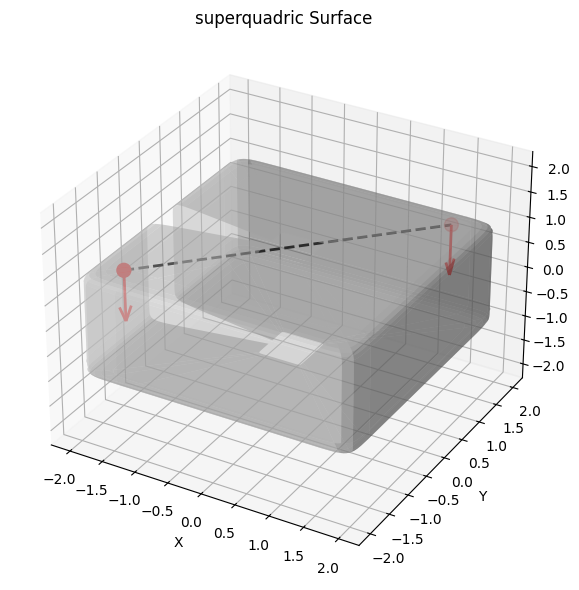

In [16]:
# Create superquadric and generate mesh
superquadric = SuperQuadric(a1=a1, a2=a2, a3=a3, e1=e1, e2=e2)
x, y, z = superquadric.generate_mesh(resolution=50)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

points = superquadric.sample_close_surface_points(epsilon=0.3, seed=None)
ax.scatter3D(*zip(*points), color='red', s=100)
ax.plot3D(*zip(*points), color='k', linewidth=2, linestyle='--')
normal_1 = -superquadric.surface_normal(*superquadric.theta_phi(points[0]))
normal_2 = -superquadric.surface_normal(*superquadric.theta_phi(points[1]))
ax.quiver(*points[0], *normal_1, color='red', length=1, linewidth=2)
ax.quiver(*points[1], *normal_2, color='red', length=1, linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('superquadric Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()

In [17]:
x1_init = points[0]
x2_init = points[1]
n1_init = -superquadric.surface_normal(*superquadric.theta_phi(x1_init))
n2_init = -superquadric.surface_normal(*superquadric.theta_phi(x2_init))
theta1_init = np.arccos((x2_init - x1_init).dot(n2_init) / np.clip(np.linalg.norm(x2_init - x1_init), a_min=1e-6, a_max=np.inf))
theta2_init = np.arccos((x1_init - x2_init).dot(n1_init) / np.clip(np.linalg.norm(x1_init - x2_init), a_min=1e-6, a_max=np.inf))

eta = 0.001

list_x1 = [x1_init.reshape(1, -1)]
list_x2 = [x2_init.reshape(1, -1)]
list_n1 = [n1_init.reshape(1, -1)]
list_n2 = [n2_init.reshape(1, -1)]
list_theta1 = [theta1_init]
list_theta2 = [theta2_init]

x1 = x1_init
x2 = x2_init
for iter_ in range(10000):
    n1 = -superquadric.surface_normal(*superquadric.theta_phi(x1))
    n2 = -superquadric.surface_normal(*superquadric.theta_phi(x2))   
    diff_vec = x2 - x1
    e = diff_vec / np.clip(np.linalg.norm(diff_vec), a_min=1e-6, a_max=np.inf)
    theta1 = np.arccos((-e*n2).sum())
    theta2 = np.arccos((e*n1).sum())

    t1 = n2 - (n2*e).sum()*e
    t2 = n1 - (n1*e).sum()*e

    t1 = t1 - (t1*n1).sum()*n1
    t2 = t2 - (t2*n2).sum()*n2

    x1 = x1 + eta*t1
    x2 = x2 + eta*t2

    x1 = superquadric.project_to_surface(x1)
    x2 = superquadric.project_to_surface(x2)

    list_x1.append(x1.reshape(1, -1))
    list_x2.append(x2.reshape(1, -1))
    list_n1.append(n1.reshape(1, -1))
    list_n2.append(n2.reshape(1, -1))
    list_theta1.append(theta1)
    list_theta2.append(theta2)

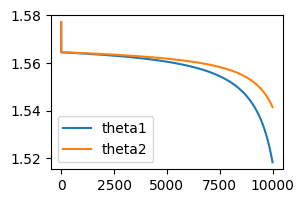

In [18]:
# plot theta as a function for iterations
plt.figure(figsize=(3, 2))
plt.plot(list_theta1, label='theta1')
plt.plot(list_theta2, label='theta2')
plt.legend()
plt.show()

In [19]:
X1_original = np.concatenate(list_x1, axis=0)
X2_original = np.concatenate(list_x2, axis=0)
N1_original = np.concatenate(list_n1, axis=0)
N2_original = np.concatenate(list_n2, axis=0)
THETA1_original = np.array(list_theta1)
THETA2_original = np.array(list_theta2)

In [20]:
video = []
skip_frame = 100
for k, (x1, x2, n1, n2, theta1, theta2) in enumerate(zip(
    X1_original[::skip_frame], 
    X2_original[::skip_frame], 
    N1_original[::skip_frame], 
    N2_original[::skip_frame], 
    THETA1_original[::skip_frame], 
    THETA2_original[::skip_frame]
)):
    superquadric = SuperQuadric(a1=a1, a2=a2, a3=a3, e1=e1, e2=e2)
    x, y, z = superquadric.generate_mesh(resolution=50)

    # Plot with matplotlib
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

    if (theta1 < 5*np.pi/180) and (theta2 < 5*np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(*zip(x1, x2), color=color, s=100)
    if color == 'green':
        ax.plot3D(*zip(x1, x2), color=color, linewidth=2, linestyle='--')
    else:
        ax.plot3D(*zip(x1, x2), color='k', linewidth=2, linestyle='--')
    ax.quiver(*x1, *n1, color=color, length=1, linewidth=2)
    ax.quiver(*x2, *n2, color=color, length=1, linewidth=2)
    set_axes_equal(ax)
    
    # add title with theta 1 and theta 2
    ax.set_title(f'Theta1: {theta1*180/np.pi:.2f} deg, Theta2: {theta2*180/np.pi:.2f} deg')

    buf = BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)  
    plt.close()
    video.append(np.array(Image.open(buf)))

In [21]:
display_video(video, framerate=30)

## Drawing a figure

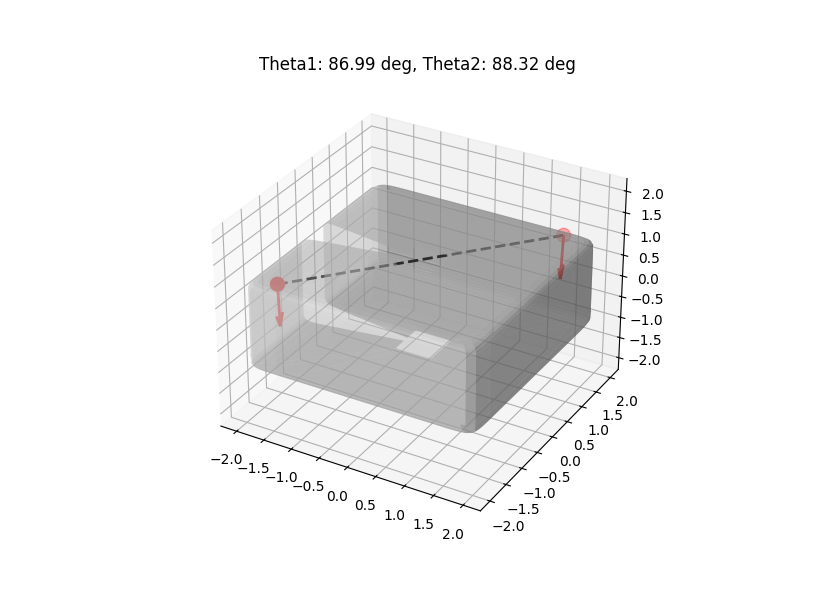

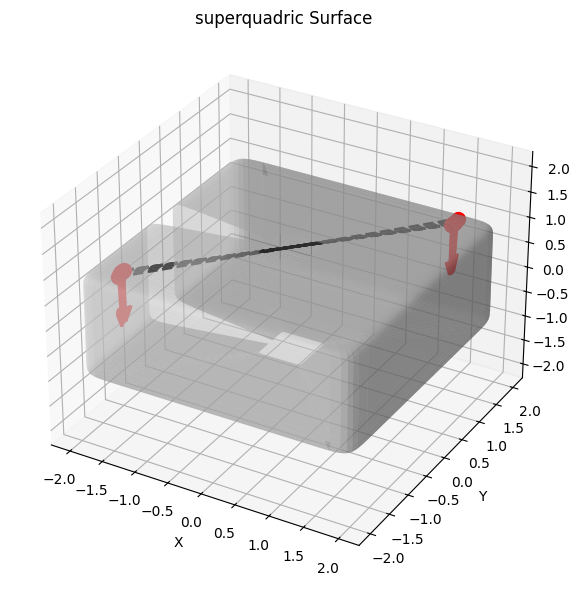

In [22]:
# slicing
X1 = X1_original[::1000]
X2 = X2_original[::1000]
N1 = N1_original[::1000]
N2 = N2_original[::1000]
THETA1 = THETA1_original[::1000]
THETA2 = THETA2_original[::1000]

# Create superquadric and generate mesh
superquadric = SuperQuadric(a1=a1, a2=a2, a3=a3, e1=e1, e2=e2)
x, y, z = superquadric.generate_mesh(resolution=100)

# Plot with matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, rstride=4, cstride=4, color='lightgrey', alpha=0.5)

# plot line conntecting X1 and X2
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'k'
    ax.plot3D([X1[i, 0], X2[i, 0]], [X1[i, 1], X2[i, 1]], [X1[i, 2], X2[i, 2]], color=color, linewidth=2, linestyle='--')
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.quiver(X1[i, 0], X1[i, 1], X1[i, 2], N1[i, 0], N1[i, 1], N1[i, 2], color=color, length=1, linewidth=2)
    ax.quiver(X2[i, 0], X2[i, 1], X2[i, 2], N2[i, 0], N2[i, 1], N2[i, 2], color=color, length=1, linewidth=2)

# scatter with different color
for i in range(X1.shape[0]):
    if (THETA1[i] <  5 * np.pi/180) and (THETA2[i] <  5 * np.pi/180):
        color = 'green'
    else:
        color = 'red'
    ax.scatter3D(X1[i, 0], X1[i, 1], X1[i, 2], color=color, s=100)
    ax.scatter3D(X2[i, 0], X2[i, 1], X2[i, 2], color=color, s=100)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('superquadric Surface')
set_axes_equal(ax)

plt.tight_layout()
plt.show()